Actividad 4 ANÁLISIS DE RESIDUOS
---

|                |   |
:----------------|---|
| **Nombre**     |  Claudio Alejo Encarnación Martínez |
| **Fecha**      |  7 septiembre 2026 |
| **Expediente** | 750597  |

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [8]:
df = pd.read_csv("/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [11]:
#Realizar regresión lineal (y=b0+b1TV+b2radio+b3newspaper)
X_TV = df['TV'].values.reshape(-1, 1)
X_Radio = df['radio'].values.reshape(-1, 1)
X_Newspaper = df['newspaper'].values.reshape(-1, 1)
ones = np.ones((len(df), 1))

ols = sm.OLS(df['sales'], np.hstack((ones, X_TV, X_Radio, X_Newspaper)))

results = ols.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        17:37:12   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

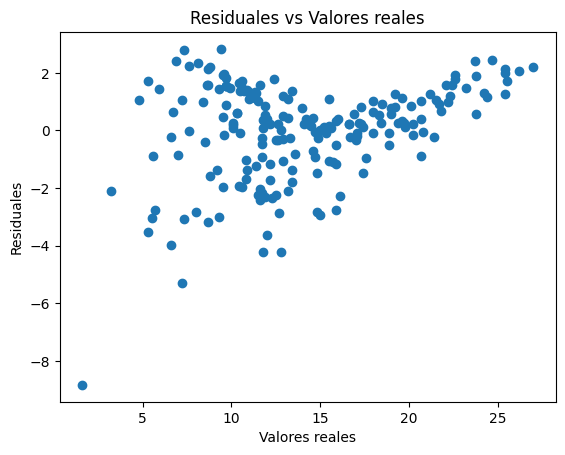

In [13]:
#Graficar errores (y-y_hat) vs y 
y_hat = results.predict(np.hstack((ones, X_TV, X_Radio, X_Newspaper)))
residuals = df['sales'] - y_hat
plt.scatter(df['sales'], residuals)
plt.xlabel('Valores reales')
plt.ylabel('Residuales')
plt.title('Residuales vs Valores reales')
plt.show()

## Instrucciones actividad en clase

Utiliza el dataset "College.csv".

Utiliza el factor Grad. Rate como variable dependiente.

Utiliza los otros factores como variables independientes.

Analiza los residuos y sus interacciones para decidir si el dataset contiene alguno de los 6 problemas comunes en una regresión.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm



In [3]:
df1 = pd.read_csv('/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/College.csv')
df1.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [11]:
#COnvertir la variable Private en una variable dummy (1 si es privada, 0 si es pública)
df1['Private'] = df1['Private'].apply(lambda x: 1 if x == 'Yes' else 0)

In [12]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           777 non-null    str    
 1   Private              777 non-null    int64  
 2   Apps                 777 non-null    int64  
 3   Accept               777 non-null    int64  
 4   Enroll               777 non-null    int64  
 5   Top10perc            777 non-null    int64  
 6   Top25perc            777 non-null    int64  
 7   F.Undergrad          777 non-null    int64  
 8   P.Undergrad          777 non-null    int64  
 9   Outstate             777 non-null    int64  
 10  Room.Board           777 non-null    int64  
 11  Books                777 non-null    int64  
 12  Personal             777 non-null    int64  
 13  PhD                  777 non-null    int64  
 14  Terminal             777 non-null    int64  
 15  S.F.Ratio            777 non-null    float64
 16  p

In [8]:
#Agregar una interacción entre Outstate y Room.Board
df1['Outstate_Room_Board'] = df1['Outstate'] * df1['Room.Board']
 

In [13]:
#Regresión lineal con OLS donde Grad.Rate es la variable dependiente (y=b0+b1Apps+b2Accept+b3Enroll+b4Top10perc+b5Top25perc+b6F_Undergrad+b7P_Undergrad+Outstate(b8+b9Room.Board)+b10Room_Board+b11Books+b12Personal+b13PhD+b14Terminal+b15S_F_Ratio+b16perc_alumni+b17Expend)

X = df1[['Private','Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Outstate_Room_Board']]
y = df1['Grad.Rate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     36.18
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           2.13e-89
Time:                        17:20:29   Log-Likelihood:                -3070.6
No. Observations:                 777   AIC:                             6179.
Df Residuals:                     758   BIC:                             6268.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  29.4155      6.966      4.223      0.000      15.741      43.090
Private                 3.1634      1.714      1.845      0.065      -0.202       6.529
Apps                    0.0013      0.000      2.982      0.003       0.000       0.002
Accept                 -0.0008      0.001     -0.905      0.366      -0.002       0.001
Enroll                  0.0025      0.002      1.062      0.289      -0.002       0.007
Top10perc               0.0607      0.072      0.842      0.400      -0.081       0.202
Top25perc               0.1318      0.055      2.392      0.017       0.024       0.240
F.Undergrad            -0.0005      0.000     -1.264      0.206      -0.001       0.000
P.Undergrad            -0.0015      0.000     -3.832      0.000      -0.002      -0.001
Outstate                0.0015      0.001      2.675      0.008       0.000       0.003
Room.Board              0.0030      0.001      2.240      0.025       0.000       0.006
Books                  -0.0022      0.003     -0.770      0.441      -0.008       0.003
Personal               -0.0017      0.001     -2.159      0.031      -0.003      -0.000
PhD                     0.0899      0.057      1.580      0.115      -0.022       0.202
Terminal               -0.0793      0.063     -1.268      0.205      -0.202       0.043
S.F.Ratio               0.0866      0.160      0.542      0.588      -0.227       0.400
perc.alumni             0.2767      0.049      5.617      0.000       0.180       0.373
Expend                 -0.0004      0.000     -2.717      0.007      -0.001      -0.000
Outstate_Room_Board -9.732e-08   1.09e-07     -0.891      0.373   -3.12e-07    1.17e-07
==============================================================================
Omnibus:                       37.013   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              100.058
Skew:                           0.168   Prob(JB):                     1.87e-22
Kurtosis:                       4.726   Cond. No.                     8.53e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.53e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

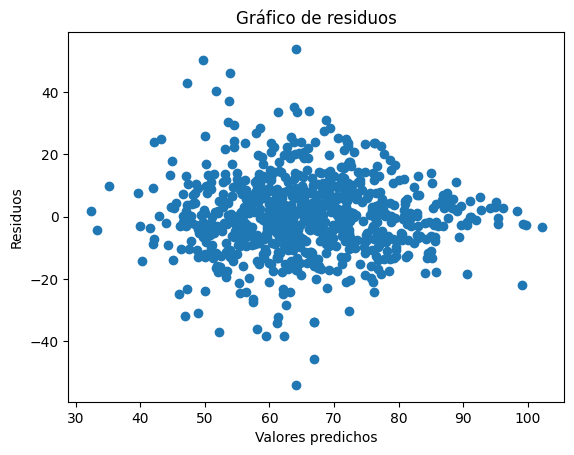

In [22]:
#Visualizar residuos
import matplotlib.pyplot as plt

plt.scatter(model.fittedvalues, model.resid)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.show()

Se puede observar intuitivamente que no hay homocedasticidad, por la forma en que se ven los datos distribuidos 

Correlación entre residuos y Private: 4.90373726813794e-11
Correlación entre residuos y Apps: -3.139531937104407e-10
Correlación entre residuos y Accept: -2.536789469895907e-10
Correlación entre residuos y Enroll: -2.2606955059541307e-10
Correlación entre residuos y Top10perc: -6.570959287064645e-10
Correlación entre residuos y Top25perc: -6.065822643584823e-10
Correlación entre residuos y F.Undergrad: -2.0782084185835266e-10
Correlación entre residuos y P.Undergrad: -3.532616597764808e-11
Correlación entre residuos y Outstate: -4.026048682851667e-10
Correlación entre residuos y Room.Board: -1.258036840228533e-10
Correlación entre residuos y Books: -6.06181069779571e-11
Correlación entre residuos y Personal: 2.5151583518529506e-11
Correlación entre residuos y PhD: -4.327047027345805e-10
Correlación entre residuos y Terminal: -4.020496308765793e-10
Correlación entre residuos y S.F.Ratio: 2.1258488546782844e-10
Correlación entre residuos y perc.alumni: -2.9605957965736116e-10
Correlación

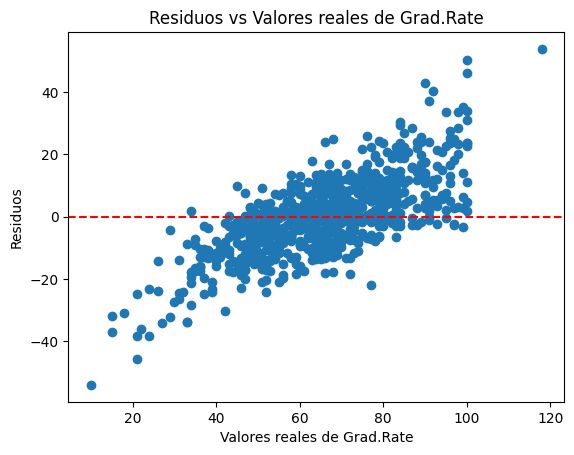

In [29]:
#Identificar correlación en errores (residuals) con variables independientes
correlations = {}
for column in X.columns:
    if column != 'const':
        correlation = np.corrcoef(model.resid, X[column])[0, 1]
        correlations[column] = correlation
        print(f"Correlación entre residuos y {column}: {correlation}")

#Visualizar E vs. Yreal para identificar heterocedasticidad
plt.scatter(y, model.resid)
plt.xlabel('Valores reales de Grad.Rate')
plt.ylabel('Residuos')
plt.title('Residuos vs Valores reales de Grad.Rate')
plt.axhline(0, color='red', linestyle='--')
plt.show()
    

In [20]:
#Identificar varianza no constante (heterocedasticidad) en errores (residuals) con variables independientes
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

test = sms.het_breuschpagan(model.resid, model.model.exog)
print(lzip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f-p-value'], test))

if test[1] < 0.05:
    print("Se rechaza la hipótesis nula: hay evidencia de heterocedasticidad.")
else:
    print("No se rechaza la hipótesis nula: no hay evidencia de heterocedasticidad.")

[('Lagrange multiplier statistic', np.float64(65.19613402388603)), ('p-value', np.float64(2.88376150217828e-07)), ('f-value', np.float64(3.8570760501979153)), ('f-p-value', np.float64(1.376884316382912e-07))]
Se rechaza la hipótesis nula: hay evidencia de heterocedasticidad.


In [21]:
#Identificar valores atípicos (outliers) con fórmula |E|/sigma >= 3
residuals = model.resid
sigma = np.std(residuals)
outliers = np.where(np.abs(residuals) / sigma >= 3)[0]
print(f"Índices de valores atípicos: {outliers}")


Índices de valores atípicos: [ 95  98 113 317 319 377 394 585 731]


In [23]:
#Identificar puntos palanca con hi>= p+1/n
influence = model.get_influence()
leverage = influence.hat_matrix_diag
p = X.shape[1]  # Número de parámetros (incluyendo la constante)
n = X.shape[0]  # Número de observaciones
leverage_threshold = (p + 1) / n
high_leverage_points = np.where(leverage >= leverage_threshold)[0]
print(f"Índices de puntos palanca: {high_leverage_points}")

Índices de puntos palanca: [  1  16  20  21  23  37  39  47  55  59  60  63  64  66  69  70  71  78
  79  85  86  91  92  95  98 100 104 113 137 138 141 142 144 149 152 158
 161 165 166 174 189 201 203 210 221 222 223 226 238 241 250 251 257 269
 273 274 275 277 279 280 284 285 292 293 298 301 303 311 317 319 333 345
 346 347 349 354 355 358 363 365 366 368 373 377 383 387 389 407 409 412
 414 418 424 430 440 442 445 446 447 455 456 457 459 461 471 482 483 484
 494 497 506 507 510 512 513 515 529 536 542 548 560 561 562 563 565 567
 569 570 573 576 578 581 582 585 591 603 605 606 607 608 609 614 619 620
 622 623 624 626 628 630 633 634 637 639 640 644 646 647 651 656 657 660
 663 664 667 669 672 676 677 678 680 684 685 686 687 690 691 692 693 694
 700 701 706 711 713 717 720 721 727 728 729 735 737 739 751 753 762 763
 775]


In [28]:
#Verificar que no haya colinealidad y si sí la hay, entre cuáles variables la hay
correlation_matrix = X.corr()

if correlation_matrix.abs().values.max() > 0.8:
    print("Hay colinealidad entre las variables.")
    high_correlation_pairs = np.where(np.abs(correlation_matrix) > 0.8)
    for i in range(len(high_correlation_pairs[0])):
        if high_correlation_pairs[0][i] != high_correlation_pairs[1][i]:
            var1 = correlation_matrix.columns[high_correlation_pairs[0][i]]
            var2 = correlation_matrix.columns[high_correlation_pairs[1][i]]
            print(f"Colinealidad entre: {var1} y {var2}")
else:
    print("No hay colinealidad entre las variables.")



No hay colinealidad entre las variables.
